In [1]:
import openeo

In [2]:
from openeo.rest.auth.config import RefreshTokenStore
RefreshTokenStore().remove()

In [5]:
connection = openeo.connect("openeo.vito.be").authenticate_oidc()

Authenticated using refresh token.


In [ ]:
connenction.describe_collection(

In [7]:
spatial_vl = {"west": 2.543335, "south": 50.677316, "east": 5.866699, "north": 51.508742}
s2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_vl,
    temporal_extent=["2019-12-01", "2020-01-01"],
    bands=["B04", "B08", "SCL"]
)

scl = s2_cube.band("SCL")
# Create a clean mask (Vegetation, Soils, Water)
clean_mask = (scl == 4) | (scl == 5) | (scl == 6)
s2_masked = s2_cube.mask(~clean_mask)

red = s2_masked.band("B04")*0.0001
nir = s2_masked.band("B08")*0.0001

ndvi = (nir-red)/(nir+red)
ndvi = ndvi.apply_dimension(process="array_interpolate_linear", dimension="t")
ndvi = ndvi.resample_spatial(resolution=1000, projection=3857, method="bilinear")
ndvi = ndvi.add_dimension(name="bands", label="ndvi", type="bands")

# Download
ndvi.execute_batch("ndvi_result.nc")

0:00:00 Job 'j-260129144721421c80241a74d6a91929': send 'start'
0:00:10 Job 'j-260129144721421c80241a74d6a91929': created (progress 0%)
0:00:15 Job 'j-260129144721421c80241a74d6a91929': queued (progress 0%)
0:00:22 Job 'j-260129144721421c80241a74d6a91929': queued (progress 0%)
0:00:29 Job 'j-260129144721421c80241a74d6a91929': queued (progress 0%)
0:00:39 Job 'j-260129144721421c80241a74d6a91929': queued (progress 0%)
0:00:52 Job 'j-260129144721421c80241a74d6a91929': running (progress 6.7%)
0:01:07 Job 'j-260129144721421c80241a74d6a91929': running (progress 8.8%)
0:01:26 Job 'j-260129144721421c80241a74d6a91929': running (progress 11.4%)
0:01:50 Job 'j-260129144721421c80241a74d6a91929': running (progress 14.4%)
0:02:20 Job 'j-260129144721421c80241a74d6a91929': running (progress 17.9%)
0:02:58 Job 'j-260129144721421c80241a74d6a91929': running (progress 21.9%)
0:03:44 Job 'j-260129144721421c80241a74d6a91929': running (progress 26.4%)
0:04:43 Job 'j-260129144721421c80241a74d6a91929': running 

<BatchJob job_id='j-260129144721421c80241a74d6a91929'>

In [4]:
import numpy as np

def get_normalized_sobel_kernel(n):
    if n % 2 == 0:
        raise ValueError("Kernel size must be odd")
    
    # 1. Generate Smoothing Vector (Pascal Row n-1)
    smoothing_vec = np.poly1d([1, 1])**(n-1)
    smoothing_vec = smoothing_vec.c
    
    # 2. Generate Difference Vector
    diff_poly = (np.poly1d([1, 1])**(n-2)) * np.poly1d([1, -1])
    diff_vec = diff_poly.c
    
    # 3. Create Matrices via Outer Product
    smoothing_vec = smoothing_vec.reshape(-1, 1)
    diff_vec = diff_vec.reshape(1, -1)
    
    Gx = np.dot(smoothing_vec, diff_vec)
    Gy = np.dot(diff_vec.T, smoothing_vec.T)
    
    # 4. Normalize
    # We divide by 2^(2N-3)
    scale_factor = 1 / (2**(2*n - 3))
    
    Gx_norm = Gx * scale_factor
    Gy_norm = Gy * scale_factor
    
    return Gx_norm, Gy_norm

# Example: 5x5 Normalized
gx_5, gy_5 = get_normalized_sobel_kernel(5)

print("Scale Factor used:", 2**(2*5 - 3)) # Should be 128
print("\nTop row of Normalized 5x5 Gx:")
print(gx_5[0])

Scale Factor used: 128

Top row of Normalized 5x5 Gx:
[ 0.0078125  0.015625   0.        -0.015625  -0.0078125]


In [10]:
gx_5

array([[ 0.0078125,  0.015625 ,  0.       , -0.015625 , -0.0078125],
       [ 0.03125  ,  0.0625   ,  0.       , -0.0625   , -0.03125  ],
       [ 0.046875 ,  0.09375  ,  0.       , -0.09375  , -0.046875 ],
       [ 0.03125  ,  0.0625   ,  0.       , -0.0625   , -0.03125  ],
       [ 0.0078125,  0.015625 ,  0.       , -0.015625 , -0.0078125]])

In [5]:
gx_7, gy_7 = get_normalized_sobel_kernel(7)

In [3]:
gx_7, gy_7

NameError: name 'gx_7' is not defined

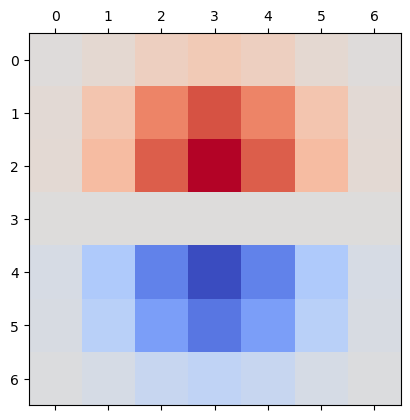

In [8]:
plt.matshow(gy_7, cmap="coolwarm")

Kernel 7x7 (Sum=-0.00000):

[[ 0.009  0.017  0.023  0.024  0.023  0.017  0.009]
 [ 0.017  0.025  0.016  0.004  0.016  0.025  0.017]
 [ 0.023  0.016 -0.044 -0.09  -0.044  0.016  0.023]
 [ 0.024  0.004 -0.09  -0.159 -0.09   0.004  0.024]
 [ 0.023  0.016 -0.044 -0.09  -0.044  0.016  0.023]
 [ 0.017  0.025  0.016  0.004  0.016  0.025  0.017]
 [ 0.009  0.017  0.023  0.024  0.023  0.017  0.009]]


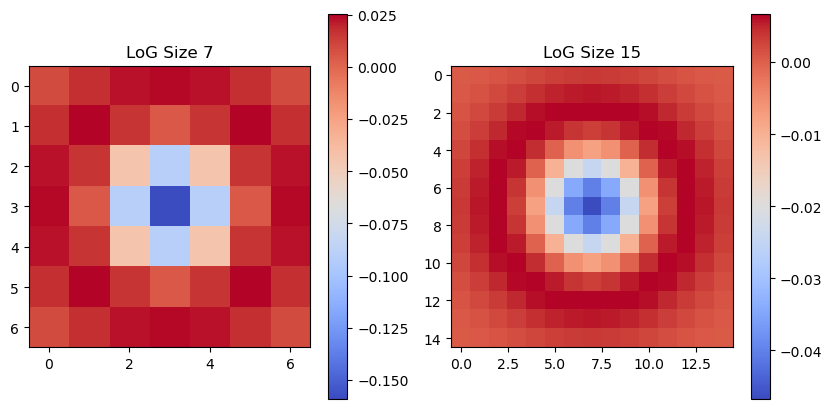

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def laplacian_of_gaussian(size, sigma=None, normalize_scale=False):
    """
    Generates a normalized discrete Laplacian of Gaussian (LoG) kernel.
    
    Args:
        size (int): The size of the kernel (must be odd, e.g., 5, 7, 15).
        sigma (float): The standard deviation of the Gaussian. 
                       If None, it is auto-calculated to fit the size.
        normalize_scale (bool): If True, multiplies by sigma^2 (scale invariance).
                                Use this if comparing blobs across different sizes.
    
    Returns:
        np.array: The NxN LoG kernel.
    """
    if size % 2 == 0:
        raise ValueError("Kernel size must be odd.")
    
    # 1. Determine Sigma if not provided
    # OpenCV standard rule: sigma = 0.3*((ksize-1)*0.5 - 1) + 0.8
    if sigma is None:
        sigma = 0.3 * ((size - 1) * 0.5 - 1) + 0.8
    
    # 2. Create Coordinate Grid
    k = size // 2
    x = np.arange(-k, k + 1)
    y = np.arange(-k, k + 1)
    X, Y = np.meshgrid(x, y)
    
    # 3. Calculate LoG Formula
    # Formula: (-1 / (pi * sigma^4)) * (1 - (x^2+y^2)/(2*sigma^2)) * exp(...)
    r2 = X**2 + Y**2
    exponent = np.exp(-r2 / (2 * sigma**2))
    
    # The term inside the bracket
    bracket = 1 - (r2 / (2 * sigma**2))
    
    # The pre-factor
    # Note: We can simplify the constant because we force sum=0 later,
    # but keeping it makes the math 'real'.
    factor = -1 / (np.pi * sigma**4)
    
    kernel = factor * bracket * exponent
    
    # 4. Enforce Zero-Sum (Crucial for Laplacian)
    # Due to discrete sampling, the mathematical LoG might not sum to exactly 0.
    # We subtract the mean to force the sum to 0.
    kernel = kernel - kernel.mean()
    
    # 5. Optional: Scale Normalization (for Blob Detection)
    # If detecting blobs, larger sigmas produce weaker responses naturally.
    # Multiplying by sigma^2 corrects this.
    if normalize_scale:
        kernel = kernel * (sigma**2)
        
    return kernel

# --- Example Usage & Visualization ---

# Generate kernels of different sizes
size_small = 7
size_large = 15

k5 = get_laplacian_of_gaussian(size_small, normalize_scale=True)
k15 = get_laplacian_of_gaussian(size_large, normalize_scale=True)

print(f"Kernel {size_small}x{size_small} (Sum={k5.sum():.5f}):\n")
print(np.round(k5, 3))

# Visualization
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title(f"LoG Size {size_small}")
plt.imshow(k5, cmap='coolwarm')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title(f"LoG Size {size_large}")
plt.imshow(k15, cmap='coolwarm')
plt.colorbar()

plt.show()